# Dependencies


In [247]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import googlemaps
from ares import logger
import os
from pathlib import Path
from dotenv import load_dotenv
from ares.utils.common import load_json, save_json
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)


df = pd.read_csv("../artifacts/data/01-raw/untouched_raw_original.csv")
train_df = pd.read_csv("../artifacts/data/01-raw/train_df.csv")
eval_df = pd.read_csv("../artifacts/data/01-raw/eval_df.csv")
geocode_path = Path("../artifacts/data/04-geocode_cache/geocode_cache.json")
maps = googlemaps.Client(key=os.getenv("GOOGLE_MAPS_KEY"))

load_dotenv()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

[2026-01-01 15:19:54,042: INFO: client: API queries_quota: 60]


In [248]:
print(train_df.shape)
print(eval_df.shape)

(12208, 31)
(3052, 31)


# Geocode localities


In [249]:
df["loc"].value_counts()

loc
East Legon                         1730
Teshie                             1236
Spintex                            1191
Adenta                              867
Accra Metropolitan                  852
Tema Metropolitan                   801
Ashaley Botwe                       610
Airport Residential Area            568
Adjiriganor                         560
Weija                               524
Oyarifa                             499
Ga West Municipal                   422
Achimota                            415
Cantonments                         390
Dome Market                         361
Kasoa                               357
Haatso                              233
Dzorwulu                            211
Ablekuma                            208
Dansoman                            201
West Legon                          201
Pokuase                             198
Ga East Municipal                   158
Oyibi                               140
Ashomang Estate                     

In [250]:
def geocode(x):
    """Geocode a location x using Google Maps API"""
    try:
        result = maps.geocode(x.lower(), region="gh")
        if result:
            lat = result[0]["geometry"]["location"]["lat"]
            lng = result[0]["geometry"]["location"]["lng"]
            return (lat, lng)
    except Exception as e:
        logger.info(f"Error geocoding {x}: {e}")
    return (None, None)


def create_cache(df):
    cache = {}
    locs = df["loc"].unique()
    for i, loc in enumerate(locs, 1):
        lat, lng = geocode(loc)
        cache[loc] = {"lat": lat, "lng": lng}

    save_json(geocode_path, cache)
    return cache


try:
    geocodes_cache = load_json(geocode_path)
except FileNotFoundError:
    geocode_path.parent.mkdir(parents=True, exist_ok=True)
    geocodes_cache = create_cache(df)


def get_lat_lng(location):
    """Fetch the latitude and longitude of a location"""
    location_lower = location.lower()
    if location_lower in geocodes_cache:
        result = geocodes_cache[location_lower]
        return (result["lat"], result["lng"])
    else:
        lat, lng = geocode(location_lower)
        geocodes_cache[location_lower] = {"lat": lat, "lng": lng}
        save_json(geocode_path, geocodes_cache)
        return (lat, lng)


[2026-01-01 15:19:54,209: INFO: common: JSON file loaded successfully from: ../artifacts/data/04-geocode_cache/geocode_cache.json]


In [251]:
# Applying to both train and eval set
train_df[["lat", "lng"]] = train_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))
eval_df[["lat", "lng"]] = eval_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))

In [252]:
missing_train = train_df[train_df["lat"].isnull()]["loc"].unique()
missing_eval = eval_df[eval_df["lat"].isnull()]["loc"].unique()

logger.warning(
    f"Train data still missing {len(missing_train)} lat/lng for: {missing_train}"
)
logger.warning(
    f"Eval data still missing {len(missing_eval)} lat/lng for: {missing_eval}"
)


[2026-01-01 15:19:59,259: WARNING: 2347945726: Train data still missing 1 lat/lng for: ['Other']]
[2026-01-01 15:19:59,261: WARNING: 2347945726: Eval data still missing 1 lat/lng for: ['Other']]


# Handling Duplicates


In [253]:
train_df = train_df.drop_duplicates(subset="url")
eval_df = eval_df.drop_duplicates(subset="url")

# Handling Price Outliers


In [254]:
train_df["price"].describe()

count    1.220800e+04
mean     1.820366e+05
std      1.513865e+07
min      1.750000e+02
25%      2.200000e+03
50%      4.500000e+03
75%      1.300000e+04
max      1.655500e+09
Name: price, dtype: float64

In [255]:
x = np.log(train_df["price"])
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"Lower bound (log): {l1:.4f}")
print(f"Upper bound (log): {l2:.4f}")
print(f"Lower bound (original): {np.exp(l1):.2f}")
print(f"Upper bound (original): {np.exp(l2):.2f}")

Lower bound (log): 5.0315
Upper bound (log): 12.1374
Lower bound (original): 153.16
Upper bound (original): 186734.41


In [256]:
def plot_price(df, cutoff=100_000, l1=l1, l2=l2):
    plt.figure(num=1, figsize=(20, 10), linewidth=1)

    plt.subplot2grid((2, 3), (0, 0))
    sns.lineplot(
        [df["price"].quantile(p / 100) for p in range(0, 101, 5)], markers=True
    )

    plt.subplot2grid((2, 3), (0, 1))
    sns.distplot(np.log(df["price"]))
    plt.axvline(x=l1, color="b", linestyle=":")
    plt.axvline(x=l2, color="b", linestyle=":")
    plt.xlabel("log(price)")

    ax = plt.subplot2grid((2, 3), (0, 2))
    sm.qqplot(np.log1p(df["price"]), stats.norm, fit=True, line="45", ax=ax)

    plt.subplot2grid((2, 3), (1, 0), colspan=3)
    red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
    df.price.plot(kind="box", xlim=(0, cutoff), vert=False, flierprops=red)

    plt.tight_layout()


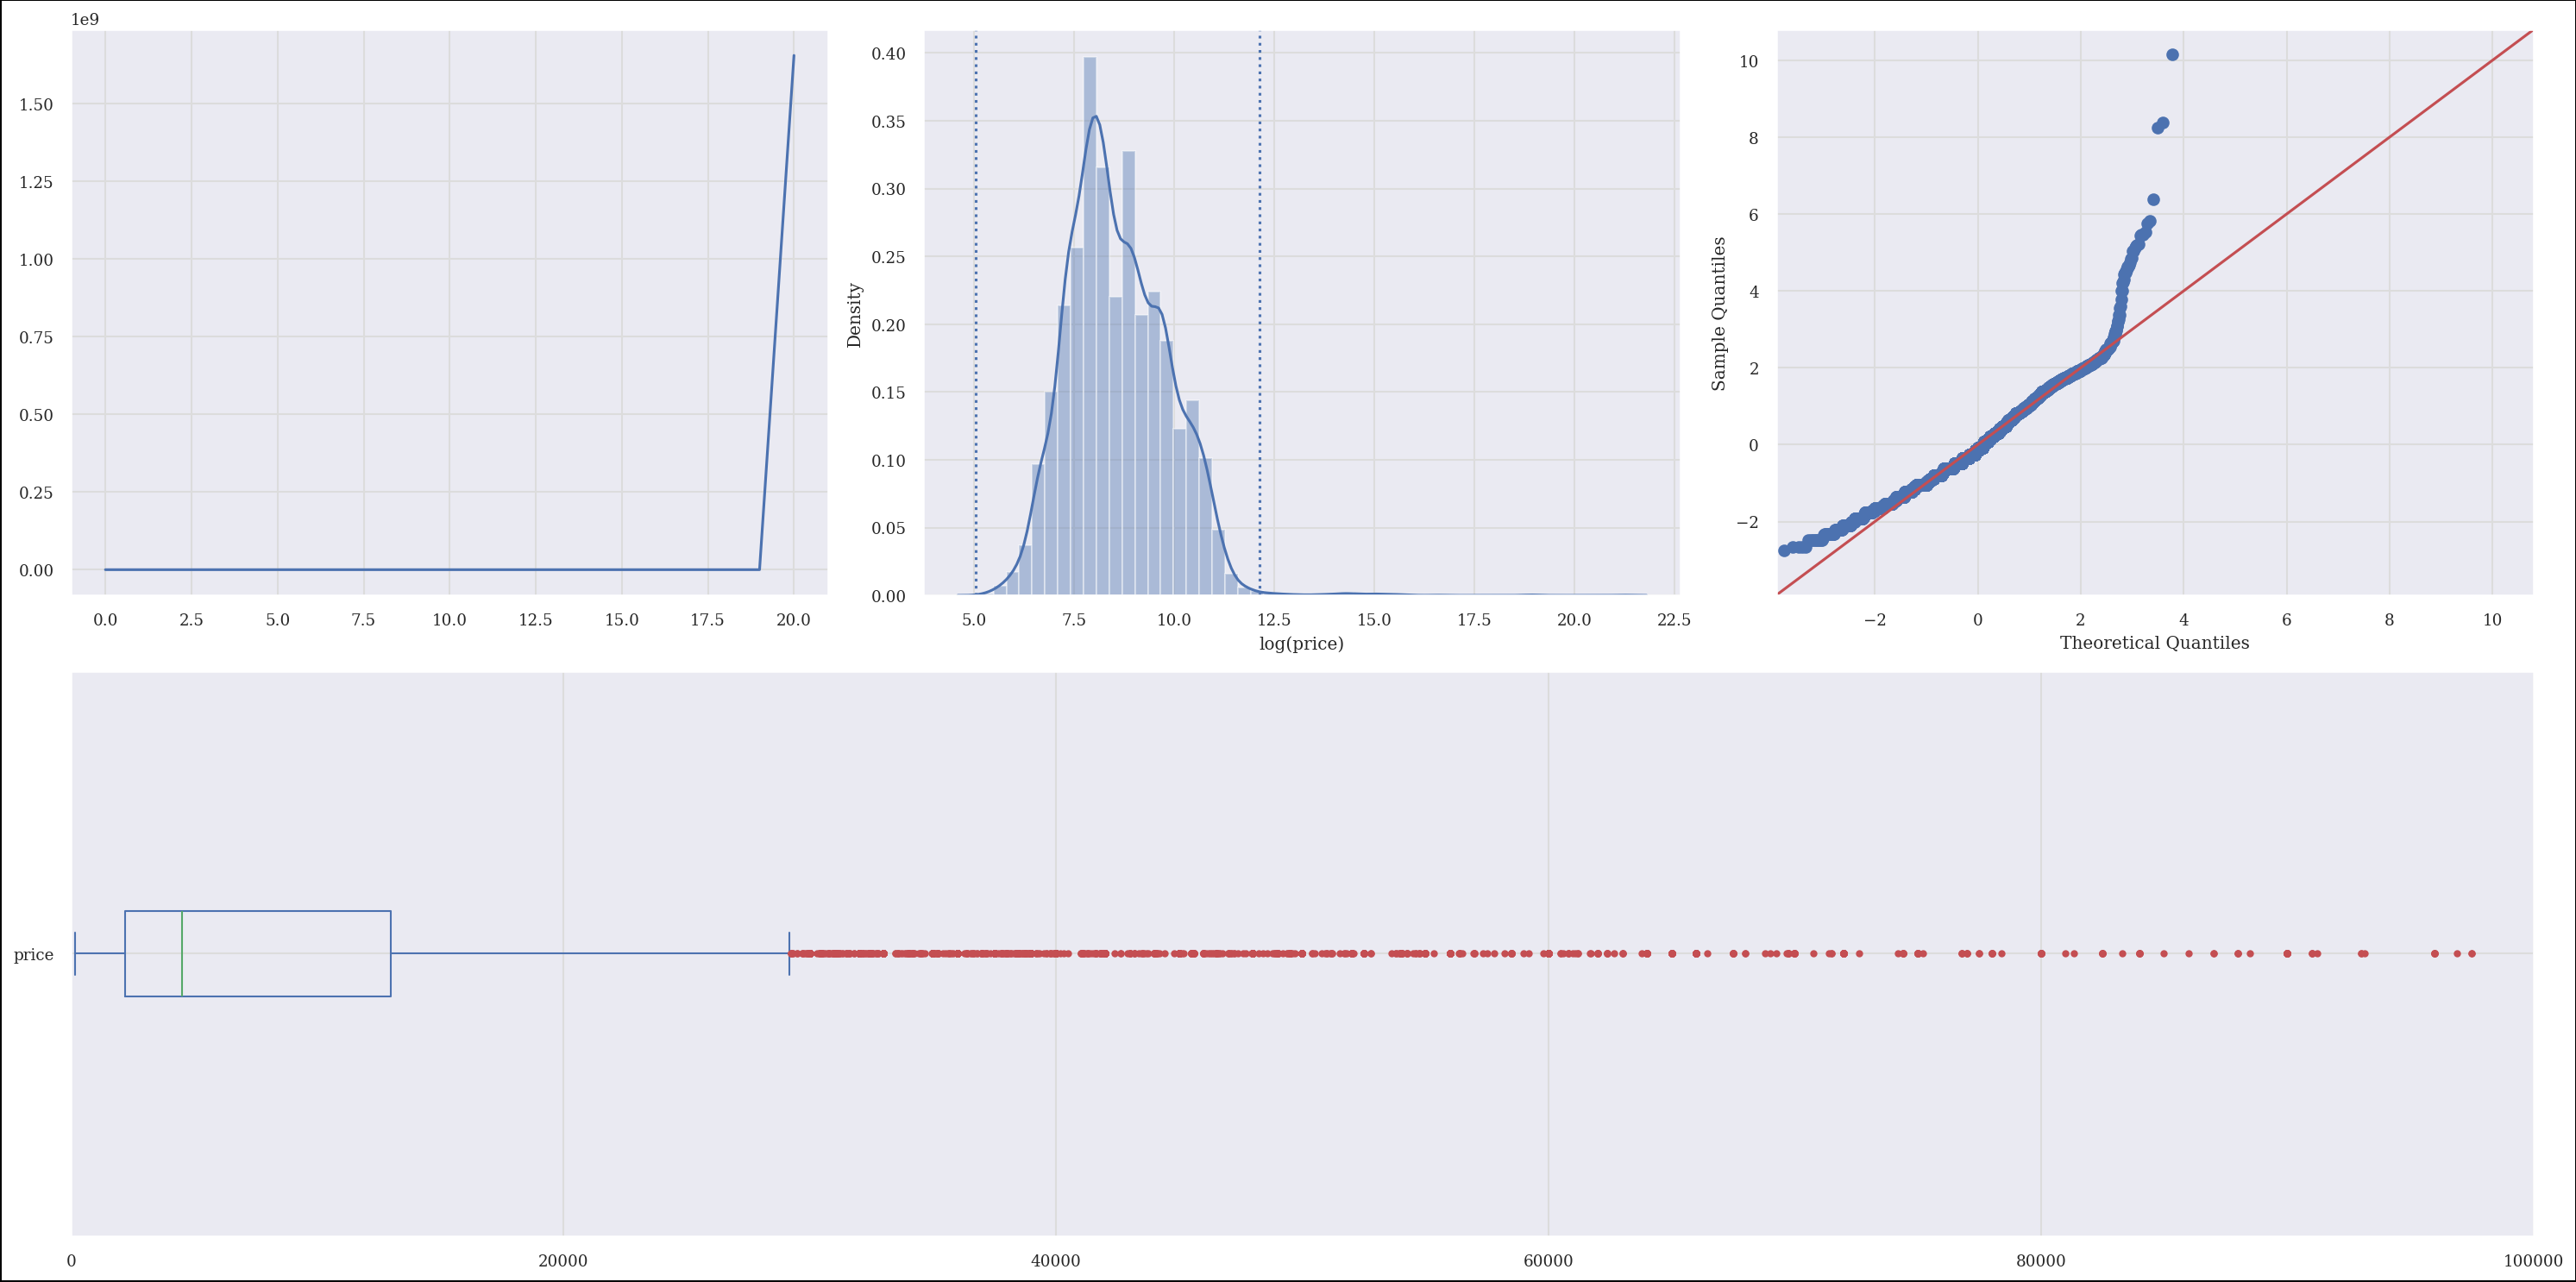

In [257]:
plot_price(train_df)

In [258]:
train_outliers = train_df[
    (np.log(train_df["price"]) < l1) | (np.log(train_df["price"]) > l2)
]

eval_outliers = eval_df[
    (np.log(eval_df["price"]) < l1) | (np.log(eval_df["price"]) > l2)
]

logger.info(
    f"{len(train_outliers)} outliers in training set and {len(eval_outliers)} outliers in evaluation set."
)

[2026-01-01 15:20:00,664: INFO: 816585731: 48 outliers in training set and 12 outliers in evaluation set.]


In [259]:
train_df = train_df.drop(index=train_outliers.index)
eval_df = eval_df.drop(index=eval_outliers.index)

Text(0.5, 1.0, 'Price distribution of training set')

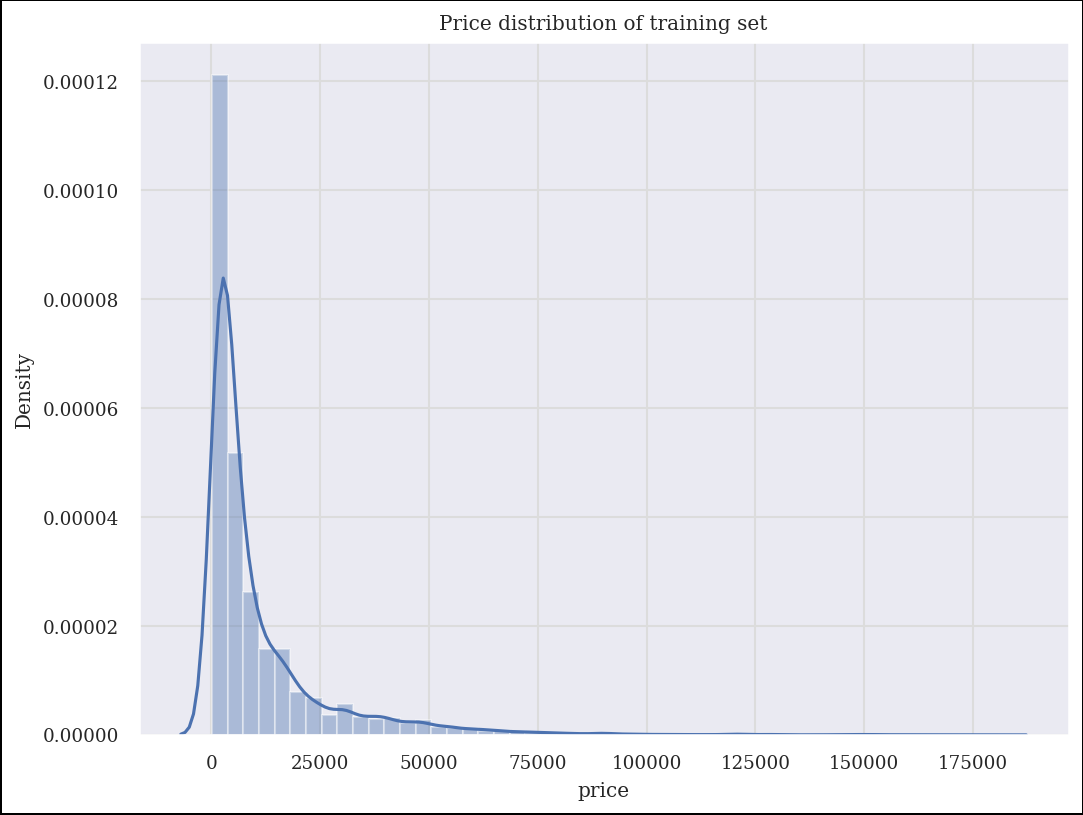

In [260]:
plt.figure(figsize=(8, 6), linewidth=1)
sns.distplot(train_df.price)
plt.title("Price distribution of training set")

# Extra Cleaning


In [261]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12160 entries, 0 to 12207
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           12160 non-null  int64  
 1   url                  12160 non-null  object 
 2   fetch_date           12160 non-null  object 
 3   house_type           12160 non-null  object 
 4   bathrooms            12160 non-null  int64  
 5   bedrooms             12160 non-null  int64  
 6   price                12160 non-null  float64
 7   locality             12160 non-null  object 
 8   Condition            12121 non-null  object 
 9   Furnishing           12160 non-null  object 
 10  Property Size        12104 non-null  float64
 11  24-hour Electricity  12160 non-null  int64  
 12  Air Conditioning     12160 non-null  int64  
 13  Apartment            12160 non-null  int64  
 14  Balcony              12160 non-null  int64  
 15  Chandelier           12160 non-null  int6

In [262]:
train_df.Condition.value_counts()

Condition
Newly-Built    5952
Fairly Used    5554
Renovated       532
Old              83
Name: count, dtype: int64

In [263]:
train_df.Condition = train_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)
eval_df.Condition = eval_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)

In [264]:
feature_columns = [
    "url",
    "house_type",
    "bathrooms",
    "bedrooms",
    "price",
    "locality",
    "lat",
    "lng",
    "Condition",
    "Furnishing",
    "24-hour Electricity",
    "Air Conditioning",
    "Apartment",
    "Balcony",
    "Chandelier",
    "Dining Area",
    "Dishwasher",
    "Hot Water",
    "Kitchen Cabinets",
    "Kitchen Shelf",
    "Microwave",
    "Pop Ceiling",
    "Pre-Paid Meter",
    "Refrigerator",
    "TV",
    "Tiled Floor",
    "Wardrobe",
    "Wi-Fi",
]

In [265]:
train_df = train_df[feature_columns]
eval_df = eval_df[feature_columns]

train_df = train_df.dropna(subset=feature_columns)
eval_df = eval_df.dropna(subset=feature_columns)

In [266]:
def rename_cols(df):
    for col in df.columns.to_list():
        df.rename(
            columns={col: col.lower().replace(" ", "_").replace("-", "_")}, inplace=True
        )
    return df

In [267]:
train_df = rename_cols(train_df)
eval_df = rename_cols(eval_df)

In [268]:
train_df.to_csv("../artifacts/data/02-preprocessed/train_df.csv", index=False)
eval_df.to_csv("../artifacts/data/02-preprocessed/eval_df.csv", index=False)

logger.info(
    f"✅ Cleaning complete, final train size: {train_df.shape}, eval size: {eval_df.shape}"
)

[2026-01-01 15:20:01,691: INFO: 469332379: ✅ Cleaning complete, final train size: (12107, 28), eval size: (3035, 28)]
